[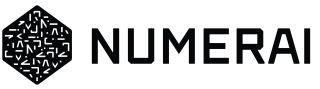](https://numer.ai/)

# Numerai Example Model Sunshine

[Numerai is "**the hardest data science tournament** in the world"](http://numer.ai/). Despite its challenging nature it is very easy to join and participate. To help you get started with building your own models, the Numerai team has built a [number of example models](https://docs.numer.ai/numerai-tournament/models). This notebook is Kaggle version of [older Sunshine example script](https://github.com/numerai/example-scripts/) (now working with latest V5.2 Faith II dataset - so it should be renamed to Faith II Example ;-) and exploring some intermediate concepts like ensembling and normalizing. If you are complete Numerai novice, you could check also these two Kaggle notebooks for quickstart:
* [Hello Numerai - NumerAPI submissions](https://www.kaggle.com/code/svendaj/hello-numerai-numerapi-submissions) - the quickest way for newcomer to complete the simple model training and submit predictions "manually" by running this notebook, dataset not updated to the latest one
* [Hello Numerai automated](https://www.kaggle.com/code/svendaj/hello-numerai-automated) - version of previous notebook prepared for upload to Numerai platform for fully automated daily submission of your predictions. This model contains also simple "tweak" to improve diagnostic performance and hopefully tournament results.

Kaggle modification of original python script are in following areas:
* There is weekly updated Kaggle dataset with full [latest version V5.2 dataset](https://forum.numer.ai/t/new-target-for-payouts-and-data-v5-2-faith-ii). Older datasets [V5.1](https://forum.numer.ai/t/data-v5-1-release-faith/8200), [V5.0](https://www.kaggle.com/datasets/svendaj/numerai-latest-tournament-data), [V4.3](https://www.kaggle.com/datasets/svendaj/numerai-v4-3-midnight), [V4.2](https://www.kaggle.com/datasets/svendaj/numerai-data-v42-rain), [V4 and V4.1 Numerai data](https://www.kaggle.com/datasets/svendaj/numerai-latest-tournament-data) are available also on Kaggle platform, but because they [will not be supported and updated after 2024-09-27](https://forum.numer.ai/t/v5-atlas-data-release/7576) there is no point in using them anymore. The latest dataset is attached to this notebook as input.
* Example script was using custom Numerai `utils` module (no more available at Numerai github), from which they imported functions and objects. This needs to be done in Kaggle as [adding utility script](https://www.kaggle.com/product-feedback/91185).
* Kaggle compute environment (12 hours of execution, 4 CPUs, 30 GB RAM) is comfortable for most tasks even in Numerai, but the training and validation data are really big  (5 mil. rows with 2400 columns) and to keep the original source code closest to original, I needed to downsample size of used data (namely because of RAM) as suggested (because of speed) in original script.

## Change log:
* **Version 2023/07/13** - adding trained model upload via NumerAPI 2.15.0
* **Version 14 2023/08/06** - predict function transposes float values to int8 dataset values 0-4, added Jim Morrison's style ending
* **Version 15 2023/08/27** - installed LightGBM 4.0.0 which is default version in Numerai environment, Kaggle default LGBM version is 3.3.2
* **Version 16 2023/09/09** - using new v4.2 Rain dataset, v4 and v4.1 datest was disconnected and new [numerai data v4.2 Rain dataset](https://www.kaggle.com/datasets/svendaj/numerai-data-v42-rain) is attached as data source
* **Version 17 2023/12/06** - using new targets engineered for better MMC performance, which will be old/new payout multiplier from Jan-2024
* **Version 18 2024/04/19** - model retrained using latest v4.3 Midnight dataset
* **Version 19 2024/09/27** - using new [V5.0 Atlas](https://forum.numer.ai/t/v5-atlas-data-release/7576) dataset, [latest version V5.0 dataset](https://www.kaggle.com/datasets/svendaj/numerai-latest-tournament-data) is attached as data source
* **Version 21 2025/11/06** - using [v5.1 Faith dataset](https://forum.numer.ai/t/data-v5-1-release-faith/8200)
* **Version 23 2025/12/18** - using [v5.2 Faith II dataset](https://forum.numer.ai/t/new-target-for-payouts-and-data-v5-2-faith-ii)

# Install and import libraries

Kaggle environment is well prepared for majority of ML and data science projects, but [Numerai official python API library](https://pypi.org/project/numerapi/) needs to be installed for each session of notebook.

In [ ]:
# https://www.kaggle.com/code/svendaj/numerai-example-model-sunshine

In [1]:
# install the same version as Numerai predict environment
!pip install -q lightgbm==4.0.0

In [2]:
# these libraries are already installed in Kaggle environment
# no need to install them
from lightgbm import LGBMRegressor
import gc, json
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

In [3]:
# NumerAPI needs to be installed
!pip install --quiet numerapi

In [4]:
# Mumerai specific imports
from numerapi import NumerAPI
from utils import (
    save_model,
    load_model,
    neutralize,
    validation_metrics,
    ERA_COL,
    DATA_TYPE_COL,
    TARGET_COL,
    EXAMPLE_PREDS_COL,
    MODEL_FOLDER
)

# Load the datasets

Because there is [weekly updated Kaggle dataset](https://www.kaggle.com/datasets/svendaj/numerai-data-v42-rain) with already downloaded data, we do not need to download it from Numerai. Dataset is attached as input to this notebook.

NumerAPI object can be instantiated anonymously whenever you need any publicly available information like current round number or download dataset. Whenever you are performing account level activities like predictions submission or model upload (which we will do later in this notebook) you will need to provide `public_id` and `secret_key` to authenticate your API calls. You can get your keys from Numerai account settings page.

Kaggle platform has feature [protecting sensitive user information](https://www.kaggle.com/discussions/product-feedback/114053) and we will use this feature for NumerAPI authentication. When you would be forking this notebook, you will need to provide `public_id` and `secret_key` of you account.

In [5]:
# load user specific secrets for NumerAPI authentication
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

public_id = user_secrets.get_secret("public_id")
secret_key = user_secrets.get_secret("secret_key")

In [6]:
# instantiate and authenticate NumerAPI client
napi = NumerAPI(public_id=public_id, secret_key=secret_key)

# when no round is open, API call fails and current round number is set to 0
try:
    current_round = napi.get_current_round()
except:
    current_round = 0
# Tournament data changes every week so we specify the round in their name. Training
# and validation data only change periodically, so no need to download them every time.
#print("Downloading dataset files...")
print(datetime.now(), f"Round number during notebook execution: {current_round}")

dataset_name = "v5.2"
feature_set_name = "medium"
path_to_dataset = "/kaggle/input/numerai-data-v5-2-faith-ii"

2025-12-18 21:52:59.966850 Round number during notebook execution: 1162


Original unused code for downloading:
```
Path(f"./{dataset_name}").mkdir(parents=False, exist_ok=True)

# we'll use the int8 in this example in order to save RAM.
# if you remove the int8 suffix for each of these files, you'll get features between 0 and 1 as floats.
# int_8 files are much smaller...
# but are harder to work with because some packages don't like ints and the way NAs are encoded.

# napi.download_dataset(f"{dataset_name}/train.parquet")
# napi.download_dataset(f"{dataset_name}/validation.parquet")
# napi.download_dataset(f"{dataset_name}/live.parquet", f"{dataset_name}/live_{current_round}.parquet")

napi.download_dataset(f"{dataset_name}/train_int8.parquet")
napi.download_dataset(f"{dataset_name}/validation_int8.parquet")
napi.download_dataset(
    f"{dataset_name}/live_int8.parquet",
    f"{dataset_name}/live_int8_{current_round}.parquet",
)

napi.download_dataset(f"{dataset_name}/validation_example_preds.parquet")
napi.download_dataset(f"{dataset_name}/features.json")
```

In [7]:
# print out round number of latest available dataset
!cat $path_to_dataset/current_round.txt

Current round: 1161

In [8]:
%%time
print(datetime.now(), f"Reading {feature_set_name} training data")
# read the feature metadata and get a feature set (or all the features)
with open(f"{path_to_dataset}/{dataset_name}/features.json", "r") as f:
    feature_metadata = json.load(f)

# features = list(feature_metadata["feature_stats"].keys()) # get all the features
# features = feature_metadata["feature_sets"]["small"] # get the small feature set

features = feature_metadata["feature_sets"][feature_set_name]  # get the medium feature set
target_cols = feature_metadata["targets"]

# read in just those features along with era and target columns
read_columns = features + target_cols + [ERA_COL, DATA_TYPE_COL]

2025-12-18 21:53:01.447406 Reading medium training data
CPU times: user 3.84 ms, sys: 774 µs, total: 4.62 ms
Wall time: 27.8 ms


In [9]:
%%time
# note: sometimes when trying to read the downloaded data you get an error about invalid magic parquet bytes...
# if so, delete the file and rerun the napi.download_dataset to fix the corrupted file

training_data = pd.read_parquet(
    f"{path_to_dataset}/{dataset_name}/train.parquet", columns=read_columns
)
validation_data = pd.read_parquet(
    f"{path_to_dataset}/{dataset_name}/validation.parquet", columns=read_columns
)
live_data = pd.read_parquet(
    f"{path_to_dataset}/{dataset_name}/live.parquet", columns=read_columns
)

# reduce the number of eras to every 4th era to speed things up... uncomment these lines to speed things up.
every_4th_era = training_data[ERA_COL].unique()[::4]
training_data = training_data[training_data[ERA_COL].isin(every_4th_era)]
every_4th_era = validation_data[ERA_COL].unique()[::4]
validation_data = validation_data[validation_data[ERA_COL].isin(every_4th_era)]


# get all the data to possibly use for training
all_data = pd.concat([training_data, validation_data])

# save indices for easier data selection later
training_index = training_data.index
validation_index = validation_data.index
all_index = all_data.index

# delete training and validation data to save space
del training_data
del validation_data
gc.collect()  # clear up memory

CPU times: user 45.3 s, sys: 19.8 s, total: 1min 5s
Wall time: 34.7 s


90

# Copy trained models

Previously trained models saved in `/kaggle/working/models` directory are attached as input of this notebook at `/kaggle/input/numerai-example-model-sunshine`. They can be copied to working directory to prevent time consuming training. To force retraining even if trained models are available, set the `RETRAIN` variable to `True`.

In [10]:
!mkdir $MODEL_FOLDER

!cp -v /kaggle/input/numerai-example-model-sunshine/$MODEL_FOLDER/*.pkl $MODEL_FOLDER

'/kaggle/input/numerai-example-model-sunshine/models/all_data_sm_lgbm_v4.1_medium_target_cyrus_v4_20.pkl' -> 'models/all_data_sm_lgbm_v4.1_medium_target_cyrus_v4_20.pkl'
'/kaggle/input/numerai-example-model-sunshine/models/all_data_sm_lgbm_v4.1_medium_target_jerome_v4_60.pkl' -> 'models/all_data_sm_lgbm_v4.1_medium_target_jerome_v4_60.pkl'
'/kaggle/input/numerai-example-model-sunshine/models/all_data_sm_lgbm_v4.1_medium_target_nomi_v4_20.pkl' -> 'models/all_data_sm_lgbm_v4.1_medium_target_nomi_v4_20.pkl'
'/kaggle/input/numerai-example-model-sunshine/models/all_data_sm_lgbm_v4.1_medium_target_ralph_v4_20.pkl' -> 'models/all_data_sm_lgbm_v4.1_medium_target_ralph_v4_20.pkl'
'/kaggle/input/numerai-example-model-sunshine/models/all_data_sm_lgbm_v4.1_medium_target_tyler_v4_20.pkl' -> 'models/all_data_sm_lgbm_v4.1_medium_target_tyler_v4_20.pkl'
'/kaggle/input/numerai-example-model-sunshine/models/all_data_sm_lgbm_v4.1_medium_target_victor_v4_20.pkl' -> 'models/all_data_sm_lgbm_v4.1_medium_tar

# Train models

... and predict with them on validation and live (out of sample) data.

In [11]:
# small fast params
params_name = "sm_lgbm"
params = {"n_estimators": 2000,
          "learning_rate": 0.01,
          "max_depth": 5,
          "num_leaves": 2 ** 5,
          "colsample_bytree": 0.1,
          "verbosity": -1, # reduce logging output
          "num_threads": 4   # number of CPUs on Kaggle
         }

# recommended params
# params_name = "lg_lgbm"
# params = {
#     "n_estimators": 20000,
#     "learning_rate": 0.001,
#     "max_depth": 6,
#     "num_leaves": 2**6,
#     "colsample_bytree": 0.1,
# }

In [12]:
# all available targets
feature_metadata["targets"]

['target_agnes_20',
 'target_agnes_60',
 'target_alpha_20',
 'target_alpha_60',
 'target_bravo_20',
 'target_bravo_60',
 'target_caroline_20',
 'target_caroline_60',
 'target_charlie_20',
 'target_charlie_60',
 'target_claudia_20',
 'target_claudia_60',
 'target_cyrusd_20',
 'target_cyrusd_60',
 'target_delta_20',
 'target_delta_60',
 'target_echo_20',
 'target_echo_60',
 'target_ender_20',
 'target_ender_60',
 'target_jasper_20',
 'target_jasper_60',
 'target_jeremy_20',
 'target_jeremy_60',
 'target_ralph_20',
 'target_ralph_60',
 'target_rowan_20',
 'target_rowan_60',
 'target_sam_20',
 'target_sam_60',
 'target_teager2b_20',
 'target_teager2b_60',
 'target_tyler_20',
 'target_tyler_60',
 'target_victor_20',
 'target_victor_60',
 'target_waldo_20',
 'target_waldo_60',
 'target_xerxes_20',
 'target_xerxes_60',
 'target']

In [13]:
# loop through all of our favorite targets and build models on each of them - one over training data, one over all available data
# for the train_data models, we'll then predict on validation data
# for the all_data models, we'll predict on live
targets = [
    "target_ender_20", # until V16
    "target_teager2b_20", # new from V17
    #"target_jerome_v4_60", # until V16
    "target_teager2b_60", # new from V17
    #"target_jeremy_v4_60", # until V16
    #"target_rowan_20",
    "target_ralph_20",
    "target_tyler_20",
    "target_victor_20",
    #"target_waldo_v4_20", # until V16
    "target_claudia_20", # new from V17
    "target_cyrusd_20"   # adding latest primary target from V16
]

In [14]:
targets

['target_ender_20',
 'target_teager2b_20',
 'target_teager2b_60',
 'target_ralph_20',
 'target_tyler_20',
 'target_victor_20',
 'target_claudia_20',
 'target_cyrusd_20']

In [15]:
prediction_cols = []
for target in tqdm(targets):
    prediction_col = f"{params_name}_{dataset_name}_{feature_set_name}_{target}"
    train_data_model_name = f"train_data_{prediction_col}"
    print(datetime.now(), f"Checking for existing model '{train_data_model_name}'")
    train_model = load_model(train_data_model_name)
    RETRAIN = True # to force retraining
    if (not train_model) or RETRAIN:
        print(datetime.now(), f"\tmodel not found, creating new one")
        train_model = LGBMRegressor(**params)
        # train on all of train and save the model so we don't have to train next time
        target_train_index = (
            all_data.loc[training_index, target].dropna().index
        )  # make sure we only train on rows which have this target
        train_model.fit(
            all_data.loc[target_train_index, features],
            all_data.loc[target_train_index, target],
        )  # in case some of the targets are missing data
        print(datetime.now(), f"\tsaving new model: {train_data_model_name}")
        save_model(train_model, train_data_model_name)

    # predict on validation data
    print(datetime.now(), "\tpredicting on validation data...")
    all_data.loc[validation_index, prediction_col] = train_model.predict(
        all_data.loc[validation_index, features]
    )
    gc.collect()

    # do the same thing for all data (for predicting on live)
    all_data_model_name = f"all_data_{prediction_col}"
    print(datetime.now(), f"Checking for existing model '{all_data_model_name}'")
    all_data_model = load_model(all_data_model_name)
    RETRAIN = True # to force retraining
    if (not all_data_model) or RETRAIN:
        print(datetime.now(), f"\tmodel not found, creating new one")
        all_data_model = LGBMRegressor(**params)
        all_data_target_index = (
            all_data.loc[all_index, target].dropna().index
        )  # make sure we only train on rows which have this target
        # train on all of train and save the model so we don't have to train next time
        all_data_model.fit(
            all_data.loc[all_data_target_index, features],
            all_data.loc[all_data_target_index, target],
        )
        print(datetime.now(), f"\tsaving new model: {all_data_model_name}")
        save_model(all_data_model, all_data_model_name)

    # predict on live data
    print(datetime.now(), "\tpredicting on live data...")
    live_data[prediction_col] = all_data_model.predict(
        live_data[features].fillna(np.nan)
    )  # filling live data with nans makes us ignore those features if necessary
    gc.collect()

    prediction_cols.append(prediction_col)

  0%|          | 0/8 [00:00<?, ?it/s]

2025-12-18 21:53:44.233838 Checking for existing model 'train_data_sm_lgbm_v5.2_medium_target_ender_20'
2025-12-18 21:53:44.234125 	model not found, creating new one
2025-12-18 22:00:06.533011 	saving new model: train_data_sm_lgbm_v5.2_medium_target_ender_20
2025-12-18 22:00:06.770513 	predicting on validation data...
2025-12-18 22:01:23.307056 Checking for existing model 'all_data_sm_lgbm_v5.2_medium_target_ender_20'
2025-12-18 22:01:23.307706 	model not found, creating new one
2025-12-18 22:15:55.540303 	saving new model: all_data_sm_lgbm_v5.2_medium_target_ender_20
2025-12-18 22:15:55.804202 	predicting on live data...


 12%|█▎        | 1/8 [22:12<2:35:26, 1332.29s/it]

2025-12-18 22:15:56.523121 Checking for existing model 'train_data_sm_lgbm_v5.2_medium_target_teager2b_20'
2025-12-18 22:15:56.527965 	model not found, creating new one
2025-12-18 22:22:13.732225 	saving new model: train_data_sm_lgbm_v5.2_medium_target_teager2b_20
2025-12-18 22:22:13.976615 	predicting on validation data...
2025-12-18 22:23:30.691527 Checking for existing model 'all_data_sm_lgbm_v5.2_medium_target_teager2b_20'
2025-12-18 22:23:30.696571 	model not found, creating new one
2025-12-18 22:37:51.900230 	saving new model: all_data_sm_lgbm_v5.2_medium_target_teager2b_20
2025-12-18 22:37:52.164504 	predicting on live data...


 25%|██▌       | 2/8 [44:08<2:12:17, 1322.93s/it]

...

 75%|███████▌  | 6/8 [2:14:03<44:46, 1343.31s/it]  

2025-12-19 00:07:47.281244 Checking for existing model 'train_data_sm_lgbm_v5.2_medium_target_claudia_20'
2025-12-19 00:07:47.289037 	model not found, creating new one
2025-12-19 00:14:04.644190 	saving new model: train_data_sm_lgbm_v5.2_medium_target_claudia_20
2025-12-19 00:14:04.896425 	predicting on validation data...
2025-12-19 00:15:23.126069 Checking for existing model 'all_data_sm_lgbm_v5.2_medium_target_claudia_20'
2025-12-19 00:15:23.134189 	model not found, creating new one
2025-12-19 00:29:45.609353 	saving new model: all_data_sm_lgbm_v5.2_medium_target_claudia_20
2025-12-19 00:29:45.874434 	predicting on live data...


 88%|████████▊ | 7/8 [2:36:02<22:15, 1335.48s/it]

2025-12-19 00:29:46.661102 Checking for existing model 'train_data_sm_lgbm_v5.2_medium_target_cyrusd_20'
2025-12-19 00:29:46.665902 	model not found, creating new one
2025-12-19 00:36:09.623264 	saving new model: train_data_sm_lgbm_v5.2_medium_target_cyrusd_20
2025-12-19 00:36:09.858224 	predicting on validation data...
2025-12-19 00:37:28.048986 Checking for existing model 'all_data_sm_lgbm_v5.2_medium_target_cyrusd_20'
2025-12-19 00:37:28.053498 	model not found, creating new one
2025-12-19 00:52:09.466734 	saving new model: all_data_sm_lgbm_v5.2_medium_target_cyrusd_20
2025-12-19 00:52:09.726322 	predicting on live data...


100%|██████████| 8/8 [2:58:26<00:00, 1338.27s/it]


# Make ensamble model and its feature neutral version

Ansamble model named `equal_weight` is created by simple averaging.

In [16]:
# make an ensemble
all_data.loc[:, "equal_weight"] = all_data.groupby(ERA_COL)[prediction_cols].rank(pct=True).mean(axis=1)
live_data["equal_weight"] = live_data[prediction_cols].rank(pct=True).mean(axis=1)

prediction_cols.append("equal_weight")

[Feature neutralization](https://forum.numer.ai/t/model-diagnostics-feature-exposure/899) is in Numerai very important concept preventing some well correlated feature to hijack prediction model. Features have significant variability and if model would be overly relying on few well correlated features, its predictions would be disproportionally damaged by changes in these features.

Winning model is created by neutralizing with selected proportion blended ensamble created in previous step. Original code was neutralizing with 50% proportion, later data seems to work better with smaller neutralization proportion. Here we are using 25% neutralization proportion.

In [17]:
%%time
# make a proportional feature neutral variation of the ensemble model
proportion = 0.25  
print(datetime.now(), "Neutralising validation prediction...")
all_data["neutral_equal_weight"] = neutralize(
    df=all_data.loc[validation_index, :],
    columns=[f"equal_weight"],
    neutralizers=features,
    proportion=proportion,
    normalize=True,
    era_col=ERA_COL,
    verbose=True,
)
# do the same for live data
print(datetime.now(), "Neutralising live prediction...")
live_data["neutral_equal_weight"] = neutralize(
    df=live_data,
    columns=[f"equal_weight"],
    neutralizers=features,
    proportion=proportion,
    normalize=True,
    era_col=ERA_COL,
    verbose=True,
)

prediction_cols.append("neutral_equal_weight")

model_to_submit = "neutral_equal_weight"

2025-12-19 00:52:14.559629 Neutralising validation prediction...


100%|██████████| 156/156 [07:34<00:00,  2.91s/it]


2025-12-19 00:59:53.698334 Neutralising live prediction...


100%|██████████| 1/1 [00:02<00:00,  2.99s/it]

CPU times: user 6min 25s, sys: 1min 16s, total: 7min 42s
Wall time: 7min 42s


# Prepare predictions for diagnostics and submission

Final selected predictions are saved to CSV files so that they can be "manually" downloaded to your computer and then uploaded to tournament as predictions `live_predictions_{current_round}.csv` or to diagnostic tool `validation_predictions_{current_round}.csv` available on [Scores page](https://numer.ai/scores) in your Numerai account.

In [18]:
# rename best model to "prediction" and rank from 0 to 1 to meet upload requirements
all_data.loc[validation_index, "prediction"] = all_data.loc[
    validation_index, model_to_submit
].rank(pct=True)
live_data["prediction"] = live_data[model_to_submit].rank(pct=True)
all_data.loc[validation_index, "prediction"].to_csv(
    f"validation_predictions_{current_round}.csv"
)
live_data["prediction"].to_csv(f"live_predictions_{current_round}.csv")

validation_example_preds = pd.read_parquet(
    f"{path_to_dataset}/{dataset_name}/validation_example_preds.parquet"
)
all_data.loc[validation_index, EXAMPLE_PREDS_COL] = validation_example_preds[
    "prediction"
]

# Calculate validation metrics

This step is optional and allows you to compare diagnostic metrics of various models/aproaches/experiments (something like public score on Kaggle competition leaderboard). Better results here are indication of model performance in live (out of sample) tournament. 

`Mean` correlation is the primary measure of your model's performance. An mean correlation above 0.02 is considered good.

`Sharpe` is a measure of your model's consistency, a concept borrowed from finance where it usually refers to risk adjusted returns of an investment strategy. In Numerai, we compute sharpe as the average correlation divided by the standard deviation of correlations. A sharpe above 1 is considered good.

`Max drawdown` is a measure of your model's risk, another concept borrowed from finance where it usually refers to the maximum financial loss suffered by an investment strategy. In Numerai, we compute max drawdown as the maximum peak to trough drop in cumulative validation correlation. A max drawdown below 0.1 in magnitude is considered good.

In [19]:
%%time
# get some stats about each of our models to compare...
# fast_mode=True so that we skip some of the stats that are slower to calculate
print(datetime.now(), "Calculating validation metrics")
validation_stats = validation_metrics(
    all_data.loc[validation_index, :],
    prediction_cols,
    example_col=EXAMPLE_PREDS_COL,
    fast_mode=True,
    target_col=TARGET_COL,
)

# Display diagnistic matrix sorted by correlation
validation_stats.sort_values(by="mean", ascending=False).dropna(axis=1)

2025-12-19 01:00:06.614985 Calculating validation metrics
CPU times: user 12min 15s, sys: 20.8 s, total: 12min 35s
Wall time: 12min 35s


,mean,std,sharpe,max_drawdown,apy,corr_with_example_preds,exposure_dissimilarity_mean
neutral_equal_weight,0.032401,0.022564,1.435946,-0.024339,366.881143,0.579101,0.346882
equal_weight,0.031914,0.022517,1.417313,-0.025487,356.297685,0.587479,0.232968
sm_lgbm_v5.2_medium_target_cyrusd_20,0.030557,0.022668,1.348035,-0.027876,327.894874,0.490101,0.570157
sm_lgbm_v5.2_medium_target_victor_20,0.030295,0.022485,1.347355,-0.023956,322.726140,0.499387,0.330947
sm_lgbm_v5.2_medium_target_ralph_20,0.029203,0.023116,1.263306,-0.023857,301.171870,0.508300,0.204459
sm_lgbm_v5.2_medium_target_claudia_20,0.029138,0.020128,1.447633,-0.030765,301.117392,0.467536,0.505797
sm_lgbm_v5.2_medium_target_ender_20,0.027974,0.021131,1.323829,-0.035982,279.221792,0.567966,0.376157
sm_lgbm_v5.2_medium_target_teager2b_20,0.027290,0.020031,1.362402,-0.035594,267.519853,0.544012,0.298331
sm_lgbm_v5.2_medium_target_teager2b_60,0.026536,0.022948,1.156326,-0.030054,253.648709,0.526661,0.280875
sm_lgbm_v5.2_medium_target_tyler_20,0.025576,0.022551,1.134125,-0.028584,237.985747,0.482573,0.205709


Original code suggesting manual submission of predictions:
```
print(
    f"""
Done! Next steps:
    1. Go to numer.ai/tournament (make sure you have an account)
    2. Submit validation_predictions_{current_round}.csv to the diagnostics tool
    3. Submit tournament_predictions_{current_round}.csv to the "Upload Predictions" button
"""
)
```

# Prepare model upload for automated submissions

Submission of predictions to tournament can be done in three ways:
1. Manually by downloading generated predictions CSV file and uploading it to Numerai platform - possibility only for experimenting and learning, but totally unrealistic for daily tournament participation
2. [Submission through NumerAPI](https://docs.numer.ai/numerai-tournament/submissions#submissions) which needs further automation. There are couple of options on how to automate:
   1. If you have AWS account, [Numerai has built two frameworks](https://docs.numer.ai/numerai-tournament/submissions#automation) to help you setup and deploy your submission pipeline. There also examples how to build similar submission pipelines on GCP, Azure or self-hosted examples.
   2. If you wish to stay in Kaggle with your models you can check, this [solution based on Linux `cron` scheduling and Kaggle API](https://www.kaggle.com/discussions/product-feedback/371090) or [trigger your Kaggle notebooks execution by webhook processed by Flask](https://www.kaggle.com/discussions/questions-and-answers/397468).
3. [Upload your model to Numerai platform](https://docs.numer.ai/numerai-tournament/submissions#model-upload) and Numerai will automatically provide daily data, execute your model and submitt resulting predictions. This [lately announced beta feature of Numerai platform](https://forum.numer.ai/t/model-upload-beta) is far superior to any other option so we will prepare this example model for upload.

In [20]:
# load trained all_data models to memory
models_list = []
prediction_cols = []
for target in targets:
    prediction_col = f"{params_name}_{dataset_name}_{feature_set_name}_{target}"
    all_data_model_name = f"all_data_{prediction_col}"
    models_list.append(load_model(all_data_model_name))
    prediction_cols.append(prediction_col)
    

In [21]:
# because cloudpickle will not serialize local libraries (utils)
# we need to define all necessary functions in memory (neutralize)
import scipy
def neutralize(
    df, columns, neutralizers=None, proportion=1.0, normalize=True, era_col="era", verbose=False
):
    if neutralizers is None:
        neutralizers = []
    unique_eras = df[era_col].unique()
    computed = []
    if verbose:
        iterator = tqdm(unique_eras)
    else:
        iterator = unique_eras
    for u in iterator:
        df_era = df[df[era_col] == u]
        scores = df_era[columns].values
        if normalize:
            scores2 = []
            for x in scores.T:
                x = (scipy.stats.rankdata(x, method="ordinal") - 0.5) / len(x)
                x = scipy.stats.norm.ppf(x)
                scores2.append(x)
            scores = np.array(scores2).T
        exposures = df_era[neutralizers].values

        scores -= proportion * exposures.dot(
            np.linalg.pinv(exposures.astype(np.float32), rcond=1e-6).dot(
                scores.astype(np.float32)
            )
        )

        scores /= scores.std(ddof=0)

        computed.append(scores)

    return pd.DataFrame(np.concatenate(computed), columns=columns, index=df.index)


In [22]:
# wrap your model with a function that takes live features and returns live predictions
def predict(live_features: pd.DataFrame) -> pd.DataFrame:
    # make predictions with primary models
    for idx in range(len(targets)):
        live_features[prediction_cols[idx]] = models_list[idx].predict(
            live_features[features]
        )
    
    # blend them together by averaging
    live_features["equal_weight"] = live_features[prediction_cols].mean(axis=1)
    # and make feature neutral prediction which will be submitted
    
    live_features["prediction"] = neutralize(
        df=live_features,
        columns=["equal_weight"],
        neutralizers=features,
        proportion=proportion,
        normalize=True,
        era_col=ERA_COL,
        verbose=False
    )
    
    return live_features["prediction"].rank(pct=True).to_frame()

In [23]:
# test predict function with  live_data
predict(pd.read_parquet(f"{path_to_dataset}/{dataset_name}/live.parquet"))

,prediction
id,
n000182caac36052,0.519291
n00099fffefb2c93,0.862655
n000a653d2c7ef9b,0.781171
n0015234b7da0e7e,0.313124
n001544a89c1c7ac,0.282884
...,...
nffecb6828f8a173,0.440191
nffedb7e2c1fdb0e,0.920602
nfff8287a852da32,0.786087


In [24]:
# name of the model in Numerai tournament
SELF_MODEL_NAME = "JOS_KAGGLE_SUNSHINE"

In [25]:
# Use the cloudpickle library to serialize your function
import cloudpickle
p = cloudpickle.dumps(predict)
pickled_model_filename = f"{SELF_MODEL_NAME}.pkl"
with open(pickled_model_filename, "wb") as f:
    f.write(p)

Now you can download `sunshine_example_predict.pkl` file from Output directory to your computer and upload it to your account at Numerai.

I have created model [JOS_KAGGLE_SUNSHINE](https://numer.ai/jos_kaggle_sunshine) in my account and uploaded this model, so you can check how it is doing.

# Upload trained model via NumerAPI

On 2023/07/13 [new version of NumerAPI](https://pypi.org/project/numerapi/) was released allowing [upload of trained and pickled model](https://numerapi.readthedocs.io/en/latest/api/numerapi.html?highlight=model_upload#numerapi.base_api.Api.model_upload) to Numerai platform for daily submission.

Following code will upload model saved by this notebook. If you would be forking this notebook, you will need `Model ID` of your model. You can get it by its name or from [Models](https://numer.ai/models) or [Submissions](https://numer.ai/submissions) page of your Numerai account.

In [26]:
%%time
# get model ID from API by its name, which is internally kept in lower case
model_id = napi.get_models()[SELF_MODEL_NAME.lower()]

# the other possibility is to copy model ID from Models or Submissions pages
# and hard code it in the notebook
#model_id = "57f4ec03-9be3-4f77-aede-8e1910ded7a5"

CPU times: user 38.1 ms, sys: 2.01 ms, total: 40.2 ms
Wall time: 303 ms


In [27]:
# check the versions of available data
napi.model_upload_data_versions()

{'v5.0 (no diagnostics)': 'bd966b6e-49f2-488a-a19c-5c61d5659cda',
 'v5.1 (no diagnostics)': 'c9fe7128-fbfc-4610-8c19-8677669a46c7',
 'v5.0': 'c9121104-003c-4dde-a48f-8d88f2f85c6e',
 'v5.1': 'c8964bce-87e3-4a4e-9d66-2e1c09ce4381',
 'v5.2 (no diagnostics)': '8baca870-b266-42f0-b804-5eb7376fa33b',
 'v5.2': '974c45e5-0be3-404f-a979-d75a1b8a5b8f'}

In [28]:
# check the available Python versions for upload
napi.model_upload_docker_images()

{'Python 3.10': '956499c9-a980-4b8d-84d5-9b339ece0071',
 'Python 3.11': '4d39918c-a82b-42ea-8dc7-ed5a30e676c5',
 'Python 3.12': 'b9b7c0db-c64b-49f0-bd7e-36056153c730'}

In [29]:
# check the Python version of the training environment
import sys
sys.version

'3.10.10 | packaged by conda-forge | (main, Mar 24 2023, 20:08:06) [GCC 11.3.0]'

In [30]:
%%time
try:
    upload_id = napi.model_upload(
        pickled_model_filename, 
        model_id=model_id,
        data_version=dataset_name,
        docker_image="Python 3.10"
    )
    print(datetime.now(), f"Model upload succeeded: {upload_id}")
except Exception as exc:
    print(datetime.now(), exc)

2025-12-19 01:13:02.985387 Model upload succeeded: 2b7d5b70-acd2-49bc-a003-ebab1b02f6da
CPU times: user 169 ms, sys: 45 ms, total: 214 ms
Wall time: 8.08 s


# Concluding remarks

Main factor in ranking individual models was [`True Contribution (TC)` ](https://forum.numer.ai/t/true-contribution-details/5128)which is almost impossible to calculate and to optimize towards, because only Numerai staff knows its formula/process. Generally it is combination of quality of predictions (measured by correlation with true results, steadiness of results measured by Sharpe ratio) and uniqueness of model (even excellent correlation does not guarrantie good TC, if large number of models have the same results). So aim for good predictions with unique approach to modelling - translated: experiment a lot with models built on solid level of data science foundations.

Few ideas for experimenting with this example model:
* grow the size of training data - with current downsampling only 1/4 of available data is used
* try different targets - there are 36 of them
* experiment with feature selection - there are 1586 features - plenty to choose from 
* play with LightGBM parameters - currently there is ongoing [grid search of hyperparameters](https://forum.numer.ai/t/super-massive-lgbm-grid-search/6463), testing influence of number of estimators, learning rate and max tree depth.
* try different ML and DeepL algorithms ([XGBoost](https://forum.numer.ai/t/numerai-quant-club-with-michael-oliver/5933/4), [NN](https://forum.numer.ai/t/neural-networks-for-numerai-signals/6334), [transformers](https://forum.numer.ai/t/using-transformers-on-numerais-stock-market-data/6003), ...)
* try different [ensembling methods](https://forum.numer.ai/t/how-to-ensemble-models/4034) - blending, stacking, bagging in all its various forms. You name it...
* ...


# The End

This is the end<br>
Beautiful friend<br>
This is the end<br>
My only friend, the end


Of our elaborate plans, the end<br>
Of everything that stands, the end<br>
No safety or surprise, the end<br>
I'll never look into your eyes again


Can you picture what will be?<br>
So limitless and free<br>
Desperately in need<br>
Of some stranger's hand<br>
In a desperate land


...


 <iframe width="560" height="315" src="https://www.youtube.com/embed/x-62d-9HLtY" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" allowfullscreen></iframe>  